## test different commits

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
# sys.path.append('../hypso')
sys.path.insert(0, '/home/ariaa/smallSatLab/hypso-package-new/hypso/')
from hypso.hypso2 import Hypso2
from hypso.hypso1 import Hypso1
from pyresample import load_area
from netCDF4 import Dataset

from hypso.write import write_l1b_nc_file, write_l1c_nc_file, write_l1d_nc_file
from hypso.spectral_analysis import get_closest_wavelength_index

In [2]:
l1a_nc_file_h1 = '/home/ariaa/smallSatLab/data/h1/lacrau_2024-12-26T10-24-27Z/lacrau_2024-12-26T10-24-27Z-l1a.nc'

In [3]:
satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [4]:
satobj_h1.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...
[INFO] Running spectral correction...


In [5]:
satobj_h1.generate_l1c_cube()

[INFO] Running direct georeferencing...
[INFO] ADCS samples: 430
[INFO] ADCS time range: 1735207980.000000 to 1735208940.000000
[INFO] Frame time range: 1735208668.028188 to 1735208717.778188
[INFO] 199 sample(s) inside frame time range
[INFO] Interpolating 598 frames
[INFO] Computing pixel latitude and longitude coordinates ...
[INFO] Interpolating pixel coordinate gaps...
[INFO] Direct georeferencing done
[INFO] Running track geometry computations...
[INFO] Using UTM map: WGS 84 / UTM zone 31N EPSG: 32631
[INFO] Track geometry computations done.
[INFO] Running angles geometry computations...
[INFO] Computing local angles (sun and satellite azimuth and zenith angles) ...
[INFO] Using astropy on a subsampling of pixels ... (TODO skyfield may be faster)
[INFO] Interpolating the rest of the pixels ...
[INFO] Computing local angles done
[INFO] Angles geometry computations done.


In [6]:
l1c_cube_h1 = satobj_h1.l1c_cube 

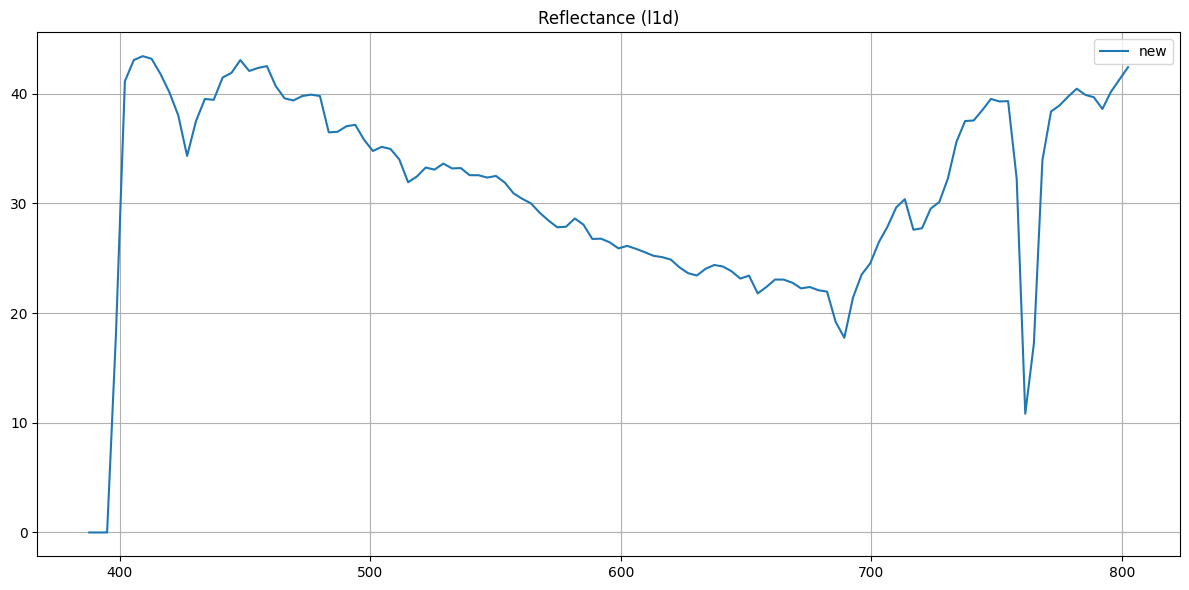

In [7]:
x_gsp_h1, y_gsp_h1 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470


plt.figure(figsize=(12,6))
plt.title('Reflectance (l1d)')
plt.plot(satobj_h1.wavelengths[:], np.array(l1c_cube_h1[x_gsp_h1, y_gsp_h1, :    ])) # wavelength mapping is not correct ...
plt.legend(['new', 'old'])
plt.grid()

plt.tight_layout()

# Compare old vs new hypso-package

In [8]:
# old hypso package vs new hypso package
# l1a_nc_file_h1 = '/home/ariaa/smallSatLab/data/h2/lacrau_2024-12-26T11-15-54Z/lacrau_2024-12-26T11-15-54Z-l1a_new.nc'
# l1c_nc_file_h1 = '/home/ariaa/smallSatLab/data/h2/lacrau_2024-12-26T11-15-54Z/lacrau_2024-12-26T11-15-54Z-l1c.nc'
l1a_nc_file_h1 = '/home/ariaa/smallSatLab/data/h1/lacrau_2024-12-26T10-24-27Z/lacrau_2024-12-26T10-24-27Z-l1a.nc'

### l1b

In [9]:
satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [10]:
satobj_h1.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...
[INFO] Running spectral correction...


In [11]:
l1b_cube_h1_old = np.load('l1b_lacrau_h1.npz')['arr_0']
l1b_cube_h1 = satobj_h1.l1b_cube

FileNotFoundError: [Errno 2] No such file or directory: 'l1b_lacrau_h1.npz'

In [ ]:
satobj_h1.generate_l1c_cube()

In [ ]:
# l1b_cube_h2_old = np.load('l1b_lacrau_h2.npz')['arr_0']
l1c_cube_h1 = satobj_h1.l1c_cube 

In [ ]:
write_l1c_nc_file(satobj=satobj_h1, overwrite=True)

### l1d

In [ ]:
satobj_h1 = Hypso1(path=l1c_nc_file_h1, verbose=True)

In [ ]:
l1b_cube_h1_old = np.load('l1b_lacrau_h1.npz')['arr_0']
l1b_cube_h1 = satobj_h1.l1b_cube 

In [ ]:
satobj_h1.generate_l1c_cube()

In [ ]:
satobj_h1.generate_l1d_cube()

In [ ]:
# write_l1d_nc_file(satobj=satobj_h1, overwrite=True)

In [ ]:
# l1d_cube_h1_old = np.load('l1d_lacrau_h1.npz')['arr_0']
l1d_cube_h1 = satobj_h1.l1d_cube 

### plot

In [ ]:
x_gsp_h1, y_gsp_h1 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470

# plt.figure(figsize=(12,6))
# plt.title('Radiance (l1b)')
# plt.plot(satobj_h1.wavelengths[:], np.array(l1b_cube_h1[x_gsp_h1, y_gsp_h1, :    ])) # wavelength mapping is not correct ...
# plt.plot(satobj_h1.wavelengths[:], np.array(l1b_cube_h1_old[x_gsp_h1, y_gsp_h1, :])) # wavelength mapping is not correct ...
# plt.legend(['new', 'old'])
# plt.grid()

# plt.tight_layout()

# plt.figure(figsize=(12,6))
# plt.title('Reflectance (l1c)')
# plt.plot(satobj_h1.wavelengths[:], np.array(l1c_cube_h1[x_gsp_h1, y_gsp_h1, :    ])) # wavelength mapping is not correct ...
# plt.plot(satobj_h1.wavelengths[:], np.array(l1b_cube_h1_old[x_gsp_h1, y_gsp_h1, :])) # wavelength mapping is not correct ...
# plt.legend(['new', 'old'])
# plt.grid()

# plt.tight_layout()

plt.figure(figsize=(12,6))
plt.title('Reflectance (l1d)')
plt.plot(satobj_h1.wavelengths[:], -np.array(l1c_cube_h1[x_gsp_h1, y_gsp_h1, :    ])) # wavelength mapping is not correct ...
# plt.plot(satobj_h1.wavelengths[:], np.array(l1d_cube_h1_old[x_gsp_h1, y_gsp_h1, :])) # wavelength mapping is not correct ...
plt.legend(['new', 'old'])
plt.grid()

plt.tight_layout()